### Bayesian Regression

In [33]:
# pip install pymc arviz

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

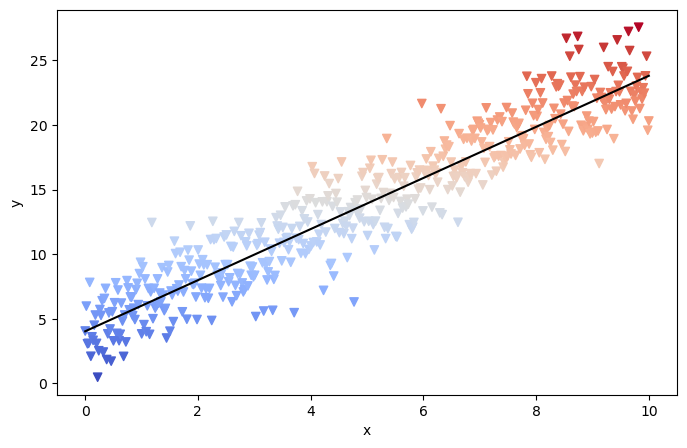

In [3]:
# Create some random data to fit 
inter = 4
slope = 2

x = np.linspace(0, 10, 500)
y = inter + slope * x + np.random.normal(loc=0, scale=2, size=len(x))

# Simple linear regression
reg = np.polyfit(x, y, deg=1)
inter = reg[1]
slope = reg[0]

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.scatter(x, y, c=y, marker='v', cmap='coolwarm')
ax.plot(x, inter + slope * x, color='black')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

We obtain as results the slope and the intecept of the regression line via OLS

In [4]:
# Bayesian model for regression

with pm.Model() as model:
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=20)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # Linear model
    mu = alpha + beta * x

    # Likelihood
    y_obs = pm.Normal("y", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [5]:
az.summary(
    trace,
    var_names=["alpha", "beta", "sigma"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,4.036,0.183,3.7,4.3,1624,1678,1.00,0.0045,0.0033
beta,1.976,0.032,1.9,2,1633,1759,1.00,0.00079,0.00056
sigma,2.04,0.066,1.9,2.2,2108,1832,1.00,0.0014,0.001


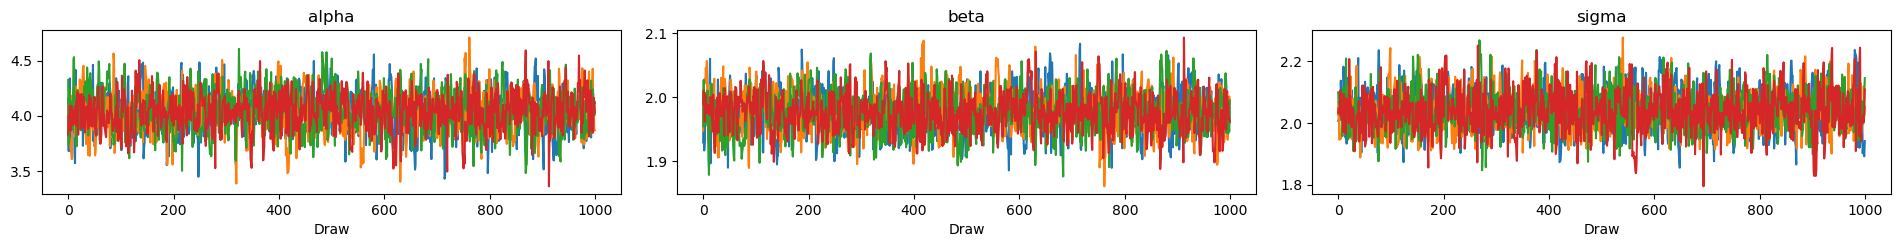

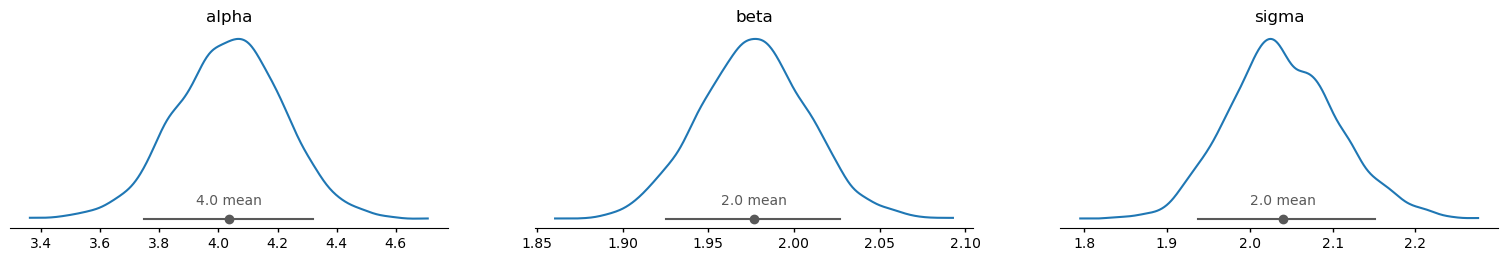

In [ ]:
az.plot_trace(
    trace,
    var_names=["alpha", "beta", "sigma"]
)

plt.tight_layout()
plt.show()

azp.plot_dist(
    trace,
    var_names=["alpha", "beta", "sigma"],
    group="posterior"
)
plt.show()

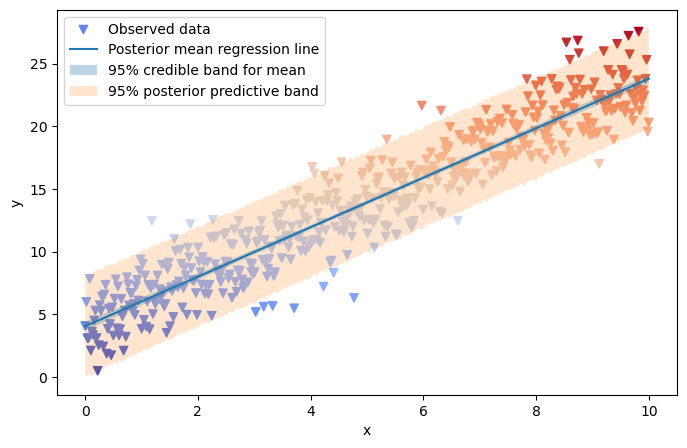

In [7]:
posterior_samples = trace["posterior"].to_dataset().stack(sample=("chain", "draw"))
alpha_samples = posterior_samples["alpha"].values
beta_samples = posterior_samples["beta"].values
sigma_samples = posterior_samples["sigma"].values

# Shape: (n_samples, n_x_points)
mu_lines = alpha_samples[:, None] + beta_samples[:, None] * x[None, :]

# Mean regression line
mu_mean = mu_lines.mean(axis=0)

# 95% interval for the mean regression line
# Important: axis=0 means across posterior samples
mu_hdi = np.quantile(mu_lines, [0.025, 0.975], axis=0).T

rng = np.random.default_rng(42)

# Add observation noise sigma
y_pred_lines = rng.normal(
    loc=mu_lines,
    scale=sigma_samples[:, None]
)

# 95% posterior predictive interval
y_pred_hdi = np.quantile(y_pred_lines, [0.025, 0.975], axis=0).T




fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.scatter(x, y, c=y, marker='v', cmap='coolwarm', label="Observed data")
ax.plot(x, mu_mean, label="Posterior mean regression line")
ax.fill_between(
    x,
    mu_hdi[:, 0],
    mu_hdi[:, 1],
    alpha=0.3,
    label="95% credible band for mean"
)
ax.fill_between(
    x,
    y_pred_hdi[:, 0],
    y_pred_hdi[:, 1],
    alpha=0.2,
    label="95% posterior predictive band"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.legend()
plt.show()

### Real Data Bayesian Regression

In [13]:
raw = pd.read_csv('~/quant_finance/python_for_finance/tr_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()
data = raw[['GDX', 'GLD']]

data = data / data.iloc[0] # Normalize so time series start at 1
data.head()

,GDX,GLD
Date,,
2010-01-04,1.000000,1.000000
2010-01-05,1.009642,0.999089
2010-01-06,1.034165,1.015574
2010-01-07,1.029134,1.009290
2010-01-08,1.044645,1.014299


<Axes: xlabel='Date'>

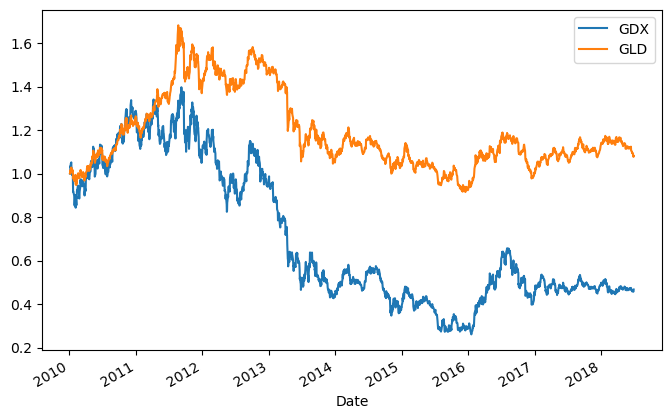

In [14]:
data.plot(figsize=(8,5))

In [15]:
data.corr()

,GDX,GLD
GDX,1.00000,0.71539
GLD,0.71539,1.00000


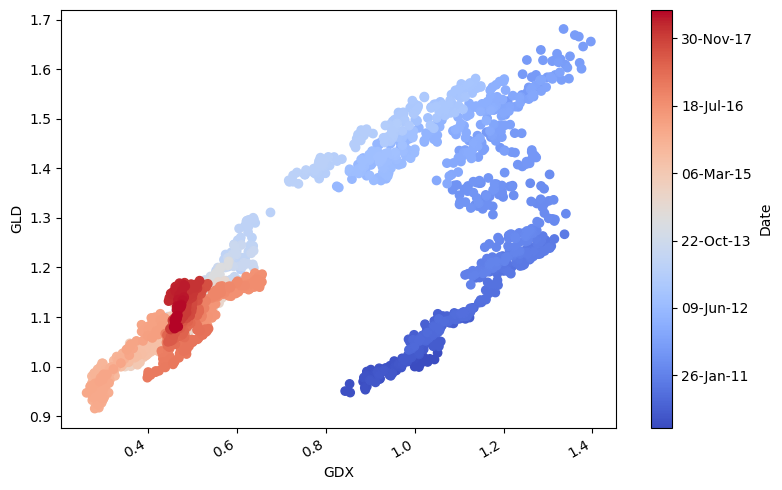

In [30]:
import matplotlib.dates as mdates

dates = pd.to_datetime(data.index)

# Convert dates to Matplotlib numeric date format
dates_num = mdates.date2num(dates)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sc = ax.scatter(
    data["GDX"],
    data["GLD"],
    marker="o",
    c=dates_num,
    cmap="coolwarm"
)
ax.set_xlabel("GDX")
ax.set_ylabel("GLD")
# Add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Date")
# Format colorbar ticks as dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [38]:
with pm.Model() as model:
    # Prior
    alpha = pm.Normal('alpha', mu=0, sd=20)
    beta = pm.Normal('beta', mu=0, sd=20)
    sigma = pm.HalfNormal('sigma', mu=0, sd=20)

    # Likelihood
    mu = alpha + beta * data['GDX'].values
    y_obs = pm.Normal("y", mu=mu, sigma=sigma, observed=data['GLD'].values)

    # Sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

    

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [39]:
az.summary(
    trace,
    var_names=["alpha", "beta", "sigma"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.914,0.0063,0.9,0.92,1538,1266,1.00,0.00016,0.00011
beta,0.3849,0.0082,0.37,0.4,1518,1504,1.00,0.00021,0.00015
sigma,0.11962,0.00178,0.12,0.12,2210,2102,1.00,3.8e-05,2.6e-05


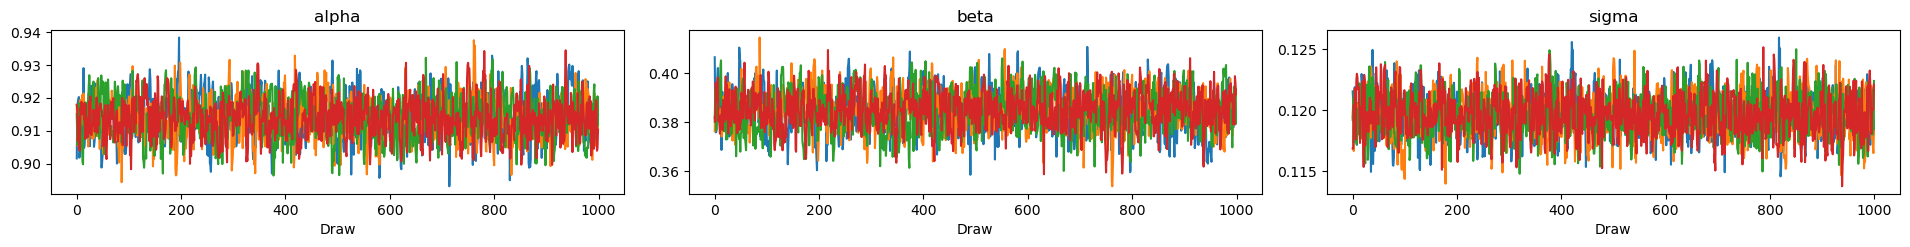

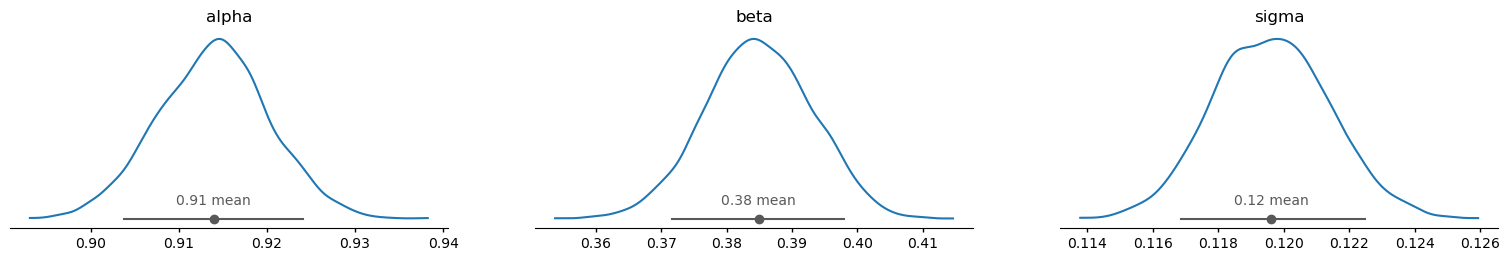

In [40]:
az.plot_trace(
    trace,
    var_names=["alpha", "beta", "sigma"]
)
plt.tight_layout()
plt.show()

azp.plot_dist(
    trace,
    var_names=["alpha", "beta", "sigma"],
    group="posterior"
)
plt.show()

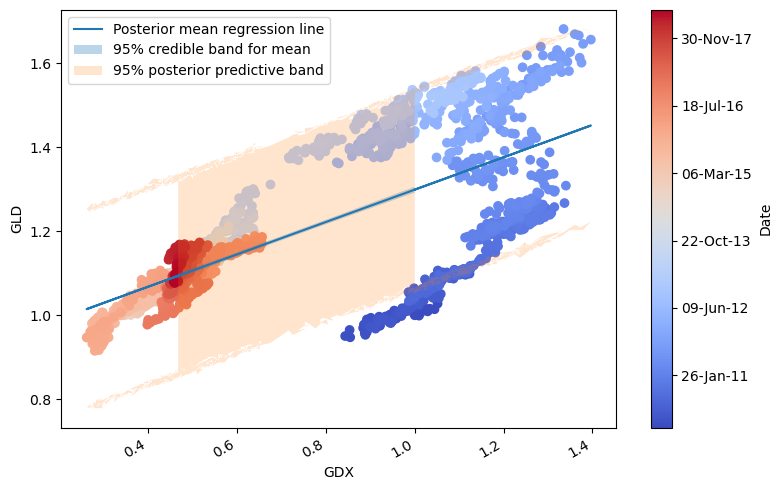

In [44]:
posterior_samples = trace["posterior"].to_dataset().stack(sample=("chain", "draw"))
alpha_samples = posterior_samples["alpha"].values
beta_samples = posterior_samples["beta"].values
sigma_samples = posterior_samples["sigma"].values
# Shape: (n_samples, n_x_points)
mu_lines = alpha_samples[:, None] + beta_samples[:, None] * x[None, :]
# Mean regression line
mu_mean = mu_lines.mean(axis=0)
# 95% interval for the mean regression line
# Important: axis=0 means across posterior samples
mu_hdi = np.quantile(mu_lines, [0.025, 0.975], axis=0).T
rng = np.random.default_rng(42)
# Add observation noise sigma
y_pred_lines = rng.normal(
    loc=mu_lines,
    scale=sigma_samples[:, None]
)
# 95% posterior predictive interval
y_pred_hdi = np.quantile(y_pred_lines, [0.025, 0.975], axis=0).T


x = data['GDX'].values
y = data['GLD'].values


fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sc = ax.scatter(
    data["GDX"],
    data["GLD"],
    marker="o",
    c=dates_num,
    cmap="coolwarm"
)

ax.plot(x, mu_mean, label="Posterior mean regression line")
ax.fill_between(
    x,
    mu_hdi[:, 0],
    mu_hdi[:, 1],
    alpha=0.3,
    label="95% credible band for mean"
)
ax.fill_between(
    x,
    y_pred_hdi[:, 0],
    y_pred_hdi[:, 1],
    alpha=0.2,
    label="95% posterior predictive band"
)

ax.set_xlabel("GDX")
ax.set_ylabel("GLD")
# Add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Date")
# Format colorbar ticks as dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d-%b-%y"))
fig.autofmt_xdate()
plt.legend()
plt.tight_layout()
plt.show()

### Updating Estimates Over Time